In [1]:
%%capture
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import Descriptors
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import AllChem
from rdkit import DataStructs
import numpy as np
import pandas as pd
from rdkit.Chem import BRICS
from collections import Counter

In [2]:
sol = pd.read_csv("SolCbio3Database_merged.csv")


smiles_list=sol['smiles']

#Los SMILES se transforman a moléculas
mol_list = []
for i in smiles_list:
    mol=Chem.MolFromSmiles(i)
    mol_list.append(mol)


sol['mols'] = mol_list
sol['dev'] = ['YES' if i > 1 else 'NO' for i in sol['diff_logS']]

In [3]:
dev_YES = sol[sol['dev'] == 'YES']
dev_NO = sol[sol['dev'] == 'NO']

In [4]:
# Function to fragment molecules using BRICS decomposition
def fragment_molecule(mol):
    fragments = list(BRICS.BRICSDecompose(mol))
    return fragments

## **Most common fragments in molecules that $\Delta\log{S} > 1$**

In [5]:
# List to store all fragments from the dataset
all_fragments = []

# Fragment each molecule and collect the fragments
for mol in dev_YES['mols']:
    if mol is not None:
        fragments = fragment_molecule(mol)
        all_fragments.extend(fragments)

# Count the occurrence of each fragment
fragment_counts = Counter(all_fragments)

# Display the most common fragments
print("Most common fragments:")
for fragment, count in fragment_counts.most_common():
    print(f"{fragment}: {count} occurrences")

Most common fragments:
[3*]O[3*]: 227 occurrences
[5*]N[5*]: 134 occurrences
[3*]OC: 102 occurrences
[16*]c1ccccc1: 101 occurrences
[1*]C([6*])=O: 75 occurrences
[4*]CC: 73 occurrences
[1*]C(C)=O: 47 occurrences
[6*]C(=O)O: 46 occurrences
[16*]c1ccc([16*])cc1: 37 occurrences
[16*]c1ccccc1[16*]: 33 occurrences
[4*]C[8*]: 31 occurrences
[4*]CC[4*]: 31 occurrences
[5*]N(C)C: 26 occurrences
[1*]C([1*])=O: 25 occurrences
[5*]N([5*])[5*]: 23 occurrences
[4*]C(C)C: 22 occurrences
[8*]CC: 22 occurrences
[12*]S(=O)(=O)c1ccc(N)cc1: 22 occurrences
[11*]S[11*]: 20 occurrences
[4*]CCO: 20 occurrences
[1*]C(=O)C[4*]: 20 occurrences
[8*]CO: 18 occurrences
[8*]C[8*]: 17 occurrences
[3*]OC[8*]: 17 occurrences
[8*]C(F)(F)F: 15 occurrences
[16*]c1ccc(Cl)cc1: 13 occurrences
[4*]CCCC: 13 occurrences
[8*]C(C)C: 13 occurrences
[4*]CC[8*]: 13 occurrences
[1*]C(=O)C[8*]: 13 occurrences
[5*]N1CCN(C)CC1: 12 occurrences
[5*]N([5*])C: 12 occurrences
[16*]c1cccc([16*])c1: 11 occurrences
[16*]c1ccc2cc([16*])ccc2c1: 

## **Most common fragments in molecules that $\Delta\log{S} < 1$**

In [6]:
# List to store all fragments from the dataset
all_fragments = []

# Fragment each molecule and collect the fragments
for mol in dev_NO['mols']:
    if mol is not None:
        fragments = fragment_molecule(mol)
        all_fragments.extend(fragments)

# Count the occurrence of each fragment
fragment_counts = Counter(all_fragments)

# Display the most common fragments
print("Most common fragments:")
for fragment, count in fragment_counts.most_common():
    print(f"{fragment}: {count} occurrences")

Most common fragments:
[3*]O[3*]: 302 occurrences
[16*]c1ccccc1: 239 occurrences
[5*]N[5*]: 198 occurrences
[3*]OC: 169 occurrences
[1*]C([6*])=O: 122 occurrences
[4*]CC: 96 occurrences
[6*]C(=O)O: 72 occurrences
[1*]C(C)=O: 67 occurrences
[16*]c1ccc(Cl)cc1: 62 occurrences
[16*]c1ccc([16*])cc1: 61 occurrences
[5*]N([5*])[5*]: 57 occurrences
[16*]c1ccccc1[16*]: 56 occurrences
[4*]C[8*]: 52 occurrences
[8*]CC: 51 occurrences
[1*]C(=O)C[4*]: 50 occurrences
[1*]C([1*])=O: 49 occurrences
[5*]N(C)C: 45 occurrences
[4*]C(C)C: 42 occurrences
[4*]CC[4*]: 39 occurrences
[4*]CCCC: 32 occurrences
[16*]c1ccc(O)cc1: 32 occurrences
[8*]CO: 31 occurrences
[8*]C(F)(F)F: 30 occurrences
[8*]C[8*]: 29 occurrences
[15*]C1([15*])C(=O)NC(=O)NC1=O: 25 occurrences
[8*]C(C)C: 24 occurrences
[9*]n1cncn1: 24 occurrences
[16*]c1ccc(Cl)cc1Cl: 23 occurrences
[16*]c1cccc([16*])c1: 23 occurrences
[5*]NC: 23 occurrences
[1*]C(=O)C[8*]: 22 occurrences
[7*]C[8*]: 21 occurrences
[1*]C(N)=O: 21 occurrences
[6*]C(=O)CO: 20 

In [13]:
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

sol['dev'] = np.where(sol['diff_logS'] > 1, 1,0)


# Build fragment frequency tables for each class
def get_fragment_freq(smiles_list):
    counts = {}
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol:
            frags = BRICS.BRICSDecompose(mol)
            for f in frags:
                counts[f] = counts.get(f, 0) + 1
    return counts


pos_frags = get_fragment_freq(sol[sol['dev']==0]['smiles'])
neg_frags = get_fragment_freq(sol[sol['dev']==1]['smiles'])
all_frags = set(pos_frags) | set(neg_frags)

n_pos, n_neg = len(sol[sol['dev']==0]), len(sol[sol['dev']==1])

results = []
for frag in all_frags:
    a = pos_frags.get(frag,0); b = n_pos - a
    c = neg_frags.get(frag,0); d = n_neg - c
    if a + c < 5: continue  #skip rare fragments
    _, pval = fisher_exact([[a,b],[c,d]], alternative='two-sided')
    results.append({'fragment': frag,
                   'pos_freq': a/n_pos,
                   'neg_freq': c/n_neg,
                   'pval': pval})

results_df = pd.DataFrame(results)
results_df['padj'] = multipletests(results_df['pval'], method = 'fdr_bh')[1]
sig = results_df[results_df['padj'] < 0.05].sort_values('neg_freq', ascending=False)


                           fragment  pos_freq  neg_freq      pval      padj
20                        [3*]O[3*]  0.168621  0.239199  0.000012  0.001387
93        [12*]S(=O)(=O)c1ccc(N)cc1  0.006142  0.023182  0.000287  0.011796
85                      [11*]S[11*]  0.006700  0.021075  0.001301  0.030288
31                       [3*]OC[8*]  0.002233  0.017914  0.000017  0.001387
95                [16*]c1ccc(Cl)cc1  0.034618  0.013699  0.001222  0.030288
150                 [12*]S(C)(=O)=O  0.000000  0.007376  0.000589  0.019210
16   [15*]C1([15*])C(=O)NC(=O)NC1=O  0.013959  0.001054  0.000289  0.011796


In [14]:
sig

,fragment,pos_freq,neg_freq,pval,padj
20,[3*]O[3*],0.168621,0.239199,0.000012,0.001387
93,[12*]S(=O)(=O)c1ccc(N)cc1,0.006142,0.023182,0.000287,0.011796
85,[11*]S[11*],0.006700,0.021075,0.001301,0.030288
31,[3*]OC[8*],0.002233,0.017914,0.000017,0.001387
95,[16*]c1ccc(Cl)cc1,0.034618,0.013699,0.001222,0.030288
150,[12*]S(C)(=O)=O,0.000000,0.007376,0.000589,0.019210
16,[15*]C1([15*])C(=O)NC(=O)NC1=O,0.013959,0.001054,0.000289,0.011796


In [36]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize

def plot_sig_fragments(sig_df, top_n=20, figsize=(10, 5), save_path=None):
    """
    Horizontal diverging bar chart of BRICS fragment enrichment.
 
    Parameters
    ----------
    sig_df : DataFrame with columns fragment/label, pos_freq, neg_freq, padj
    top_n  : show only the top_n fragments by |neg_freq - pos_freq|
    """
    df = sig_df.copy()
    df["diff"] = df["neg_freq"] - df["pos_freq"]
    df = df.reindex(df["diff"].abs().sort_values(ascending=False).index).head(top_n)
    df = df.sort_values("diff")  # so largest bars appear at top when plotted
 
    fig, ax = plt.subplots(figsize=figsize)
 
    # Fixed colors by enrichment direction (color saturation no longer encodes padj)
    COLOR_POS = "#322982"   # enriched in positive class (accurate GSE)
    COLOR_NEG = "#5d5d5c"   # enriched in negative class (inaccurate GSE)
 
    colors = [COLOR_NEG if d > 0 else COLOR_POS for d in df["diff"]]
 
    y_pos = np.arange(len(df))
    bars = ax.barh(y_pos, df["diff"], color=colors, edgecolor="black", linewidth=0.4, height=0.65)
 
    # Zero reference line
    ax.axvline(0, color="black", linewidth=1)
 
    # Fragment labels on y-axis
    ax.set_yticks(y_pos)
    ax.set_yticklabels(df["fragment"], fontsize=9)
 
    # Annotate padj next to each bar
    for y, (diff, padj) in zip(y_pos, zip(df["diff"], df["padj"])):
        q_label = f"q = {padj:.1e}" if padj < 0.001 else f"q = {padj:.3f}"
        offset = 0.005 if diff >= 0 else -0.005
        ha = "left" if diff >= 0 else "right"
        ax.text(diff + offset, y, q_label, va="center", ha=ha, fontsize=7.5, color="dimgray")
 
    ax.set_xlabel("Frequency difference  (Negative class − Positive class)", fontsize=11)

 
    # Reserve headroom above the bars for the direction legend (avoids overlap)
    ax.set_ylim(-0.7, len(df) + 1.0)
    xmax = max(abs(df["diff"].min()), abs(df["diff"].max())) * 1.15
    ax.set_xlim(-xmax, xmax)
    legend_y = len(df) + 0.4
    ax.text(-xmax * 0.98, legend_y, "← enriched in positive class (accurate GSE)",
            fontsize=8.5, va="center", ha="left", color=COLOR_POS, fontweight="bold")
    ax.text(xmax * 0.98, legend_y, "enriched in negative class (inaccurate GSE) →",
            fontsize=8.5, va="center", ha="right", color=COLOR_NEG, fontweight="bold")
 
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
 
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    return fig, ax
 
 

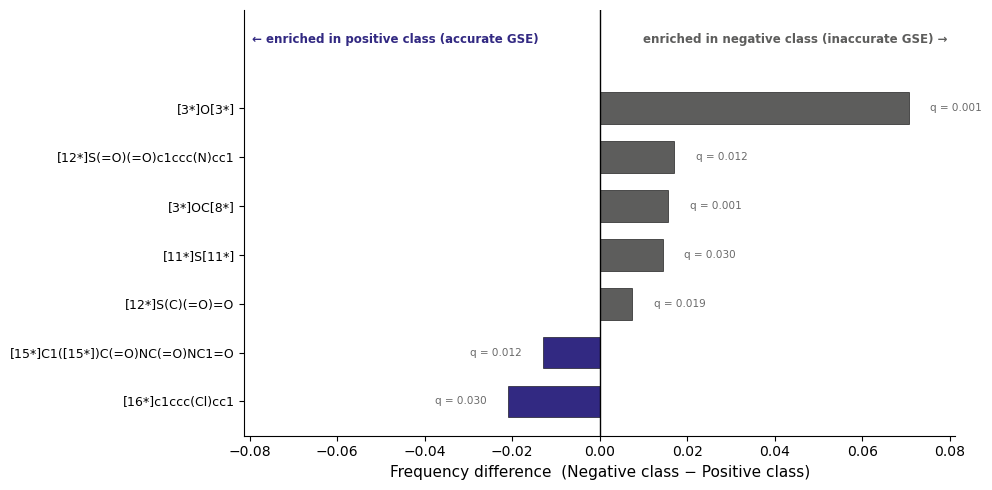

In [37]:
fig, ax = plot_sig_fragments(sig, top_n=15, save_path="brics_fragment_enrichment.pdf")
plt.show(fig)